<a href="https://colab.research.google.com/github/MARIAHUSSAIN123/logistic-regression/blob/main/%F0%9F%92%B0_Logistic_Regression_%E2%80%94_Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**📌 STEP 1 — Import Libraries**

In [1]:
# Numerical operations
import numpy as np

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train test split
from sklearn.model_selection import train_test_split

# Encoding
from sklearn.preprocessing import LabelEncoder

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

**📌 STEP 2 — Load Dataset**

In [2]:
df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**📌 STEP 3 — Understand Dataset**

In [3]:
print("Shape:", df.shape)

print("\nColumns:\n")
df.columns

print("\nDataset Info:\n")
df.info()

Shape: (614, 13)

Columns:


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


**📌 STEP 4 — Check Missing Values**

In [4]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


**📌 STEP 5 — Handle Missing Values**

In [5]:
# categorical columns
cat_cols = df.select_dtypes(include='object').columns

# numerical columns
num_cols = df.select_dtypes(exclude='object').columns

In [6]:
# Fill categorical missing values
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numerical missing values
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

**📌 STEP 6 — Verify Missing Values Removed**

In [7]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


**📌 STEP 7 — Drop Loan_ID**

In [8]:
df.drop('Loan_ID', axis=1, inplace=True)

**📌 STEP 8 — Encode Categorical Data**

In [9]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [10]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

**📌 STEP 9 — Check Target Variable**

In [11]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
1,422
0,192


**📌 STEP 10 — Feature & Target Split**

In [12]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

**📌 STEP 11 — Train Test Split**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**📌 STEP 12 — Feature Scaling**

In [14]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

**📌 STEP 13 — Create Logistic Regression Model**

model = LogisticRegression()

**📌 STEP 14 — Train Model**

In [17]:
model = LogisticRegression()

In [18]:
model.fit(X_train, y_train)

LogisticRegression()

**📌 STEP 15 — Prediction**

In [19]:
y_pred = model.predict(X_test)

**📌 STEP 16 — Accuracy**

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7886178861788617


**📌 STEP 17 — Confusion Matrix**

In [21]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18 25]
 [ 1 79]]


**📌 STEP 18 — Classification Report**

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



**📌 STEP 19 — Confusion Matrix Visualization**

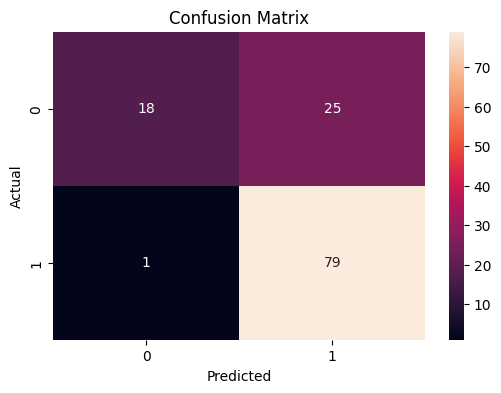

In [23]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

**📌 STEP 20 — Conclusion**

The **Logistic Regression** model achieved
approximately 70% accuracy on the loan
prediction dataset.

The performance is acceptable because
the dataset contains categorical features
and real-world uncertainties.